In [1]:
import json
import pandas as pd
import datetime
from langdetect import detect
from langcodes import *
from collections import Counter
import datetime
import pytz
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns

In [2]:
posts = []
dates = []

json_file = open('r_threebodyproblem_posts.jsonl') 
for line in json_file:
    json_data = json.loads(line)
    if 'selftext' in json_data and len(json_data['selftext'].strip())>0:
        posts.append(json_data['selftext'].strip())

    utc_date = json_data['created_utc']
    post_datetime = pytz.utc.localize(datetime.datetime.utcfromtimestamp(utc_date)).strftime("%Y-%m-%d")
    dates.append(datetime.datetime.strptime(post_datetime,'%Y-%m-%d'))
    

# Exploratory analysis

In [3]:
print(f'This data set contains {len(posts)} posts.')

This data set contains 12907 posts.


In [4]:
dates_count = Counter(dates)

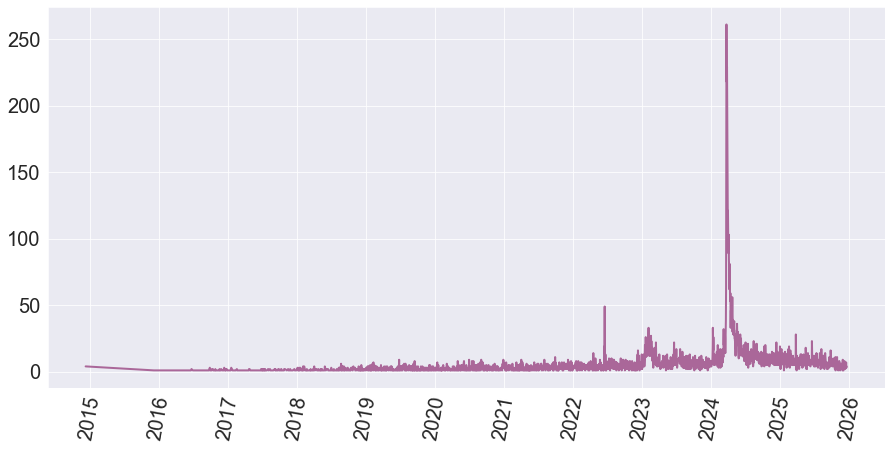

In [5]:
x_axis = dates_count.keys()
y_axis = dates_count.values()

sns.set_style('darkgrid')


fig,ax = plt.subplots(figsize=( 15 , 7 ))
ax = sns.lineplot(x=x_axis, y=y_axis, 
                  color= '#AA6799', linestyle='solid',linewidth=2 )

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis='both', labelsize=20)

plt.xticks(rotation= 80)
plt.show()

# Languages

Are all discussions in the English language? Or are Chinese users expressing themselves in their own language (linguistic analysis)?

In [6]:
languages = []
english_posts = []

for post in posts:
    try:
        language_code = detect(post)
        languages.append(Language.make(language=language_code).display_name())
        if language_code == 'en':
            english_posts.append(post.strip())
    except:
        print(f'Language could not be detected for {post}')

Language could not be detected for http://www.project-57.org/
Language could not be detected for https://www.outerplaces.com/science/item/17464-scientists-found-proof-fourth-dimension
Language could not be detected for http://neurosciencenews.com/holography-brain-activity-8918/
Language could not be detected for https://www.forbes.com/sites/startswithabang/2018/08/07/is-humanity-about-to-accidentally-declare-interstellar-war-on-alien-civilizations?share=1b18f133#301cf8b960c8
Language could not be detected for https://youtu.be/RXbFP2V_zSA
Language could not be detected for https://www.scmp.com/news/china/society/article/2163748/real-power-behind-chinas-new-trend-sissy-men-empowered-modern?share=99218820
Language could not be detected for [https://imgur.com/gallery/exfJuRK](https://imgur.com/gallery/exfJuRK)
Language could not be detected for [](http://news.mit.edu/2018/laser-attract-alien-astronomers-study-1105)
Language could not be detected for [https://www.bilibili.com/video/av439811

Language could not be detected for https://preview.redd.it/eb2ojnec233d1.png?width=982&format=png&auto=webp&s=2b2024192d331c8e6d996106c3f4eb20677afb4e
Language could not be detected for https://preview.redd.it/0fhzn01a2j3d1.jpg?width=500&format=pjpg&auto=webp&s=0a9ddd8da000178c4d985ba01eed5e3af353cc2a
Language could not be detected for https://www.facebook.com/share/P7UGir7a3ewYnCfQ/?mibextid=WC7FNe
Language could not be detected for https://www.reddit.com/r/CuratedTumblr/s/Fi5e7mRqZy
Language could not be detected for https://reddit.com/link/1dqttxb/video/8qalhis7kd9d1/player
Language could not be detected for https://preview.redd.it/7y485ohnaxad1.png?width=776&format=png&auto=webp&s=7474eba5a6cef82d4be35fd5d3fea6d3fe81352d
Language could not be detected for https://youtu.be/BRK1N49OSe4?si=5X2JZGSByy2TRTNs
Language could not be detected for https://preview.redd.it/69cscjin55gd1.png?width=1282&format=png&auto=webp&s=9ea0cbe04040bccd854dd1bc28c86c6a8f4554cc
Language could not be detecte

Language could not be detected for https://www.the-sun.com/tech/14352050/alien-communication-askap-radio-signal-telescope-nasa/
Language could not be detected for https://www.reddit.com/r/CombatFootage/s/5387Gctqzj
Language could not be detected for >
Language could not be detected for https://youtu.be/X0SvgT9Lc2M?si=8dDjiWfoThKSyqjZ
Language could not be detected for [https://www.youtube.com/watch?v=iXO-QIiJw0A](https://www.youtube.com/watch?v=iXO-QIiJw0A)
Language could not be detected for .
Language could not be detected for https://www.scientificamerican.com/article/jwst-spots-possible-alien-planet-at-alpha-centauri/
Language could not be detected for https://www.scientificamerican.com/article/jwst-spots-possible-alien-planet-at-alpha-centauri/
Language could not be detected for https://preview.redd.it/mxuyz71upohf1.png?width=645&format=png&auto=webp&s=5f446f3fa2a2d1814a15cd8985cc1a10d51f79b7
Language could not be detected for https://youtu.be/SiZanKKLrL0?si=SP65kJFf0dDWQRO5
Langua

In [7]:
language_freq = Counter(languages)

for language,count in language_freq.most_common():
    print(f'{language} => {count}')

English => 10944
Slovenian => 1076
Danish => 565
Somali => 52
German => 11
Catalan => 9
Afrikaans => 9
Polish => 8
Spanish => 8
Italian => 7
Tagalog => 6
Dutch => 6
Indonesian => 6
Turkish => 5
Norwegian => 5
Unknown language [zh-cn] => 5
Romanian => 5
Portuguese => 5
Welsh => 5
Finnish => 4
Czech => 4
French => 4
Estonian => 4
Swahili => 3
Swedish => 3
Vietnamese => 3
Lithuanian => 2
Korean => 2
Russian => 2
Croatian => 1
Tamil => 1
Latvian => 1


In [8]:
filtered = {x: count for x, count in language_freq.items() if count < 100}

In [9]:
languages_freq_below100 = Counter()
for x,count in filtered.items():
    languages_freq_below100[x] = count

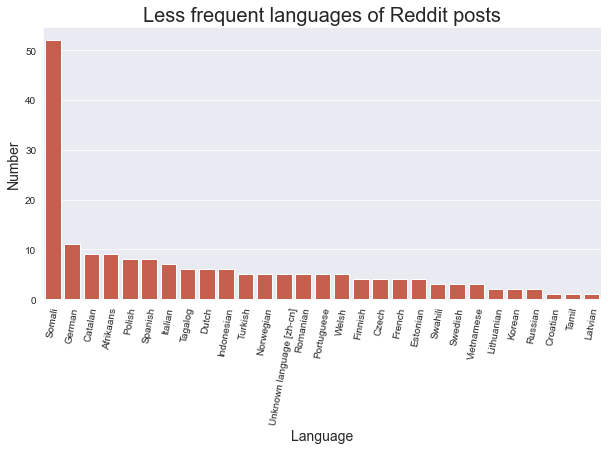

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

x_axis = []
y_axis = []

for language,count in languages_freq_below100.most_common():
    x_axis.append(language)
    y_axis.append(count)


fig = plt.figure( figsize=( 10 , 5 ) )


graph = sns.barplot(  x=x_axis, y=y_axis , color = '#d9523b')

graph.set_title('Less frequent languages of Reddit posts' , size = 20) 
graph.set_xlabel('Language' , size = 14) 
graph.set_ylabel('Number' , size = 14 )

plt.xticks(rotation=80)


plt.show()

# Keyword analysis

What are primary keywords in the discussions we find on this forum?

In [11]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stopwords = stopwords.words('english')

words_freq = Counter()

def remove_punctuation_and_stopwords(words):
    new_list= []
    for w in words:
        if w.isalnum() and w not in stopwords:
            new_list.append( w )
    return new_list

for post in english_posts:
    words = word_tokenize(post.lower())
    words = remove_punctuation_and_stopwords(words)
    words_freq.update(words)


In [12]:
for word,count in words_freq.most_common():
    print(f"{word} ({count})")

would (6626)
like (6009)
book (5984)
one (4004)
could (3751)
even (3230)
first (3193)
think (3171)
series (3169)
time (3154)
read (3017)
books (3008)
know (2892)
dark (2846)
show (2752)
earth (2750)
end (2707)
also (2656)
universe (2621)
really (2506)
forest (2502)
humanity (2418)
people (2354)
way (2240)
https (2145)
get (2112)
story (2043)
space (2037)
much (2035)
see (1899)
liu (1857)
something (1855)
cheng (1809)
make (1762)
problem (1759)
luo (1725)
years (1722)
chinese (1710)
ji (1696)
three (1689)
system (1655)
reading (1628)
world (1578)
netflix (1565)
humans (1559)
xin (1557)
trisolarans (1550)
still (1508)
human (1505)
death (1456)
body (1436)
made (1433)
light (1418)
two (1394)
characters (1346)
civilization (1339)
3 (1311)
never (1294)
2 (1292)
trisolaris (1280)
finished (1271)
us (1265)
sophons (1256)
many (1240)
thought (1237)
character (1233)
life (1227)
want (1223)
feel (1212)
good (1203)
part (1192)
science (1192)
point (1180)
seems (1179)
love (1179)
ye (1173)
cixin (

box (49)
expanse (49)
twist (49)
central (49)
aka (49)
mere (49)
gift (49)
cutting (49)
refers (49)
governments (49)
doctor (49)
threats (49)
hack (49)
http (48)
wrap (48)
express (48)
sections (48)
trap (48)
seek (48)
convince (48)
driving (48)
powers (48)
travelling (48)
naturally (48)
whereas (48)
sleep (48)
importance (48)
anime (48)
evolved (48)
sets (48)
score (48)
hits (48)
origin (48)
features (48)
sentient (48)
golden (48)
regular (48)
audible (48)
projects (48)
mainstream (48)
russian (48)
reaches (48)
stands (48)
wondered (48)
heroes (48)
properly (48)
iii (48)
facts (48)
treated (48)
folks (48)
function (47)
practically (47)
enormous (47)
station (47)
collapsed (47)
display (47)
writes (47)
realised (47)
fog (47)
spacetime (47)
prepare (47)
exchange (47)
layer (47)
disrupt (47)
immediate (47)
imply (47)
circle (47)
situations (47)
introduce (47)
subsequent (47)
2018 (47)
irl (47)
luck (47)
naive (47)
color (47)
continuing (47)
task (47)
blew (47)
eat (47)
exploring (47)
hun

conservation (20)
negotiate (20)
boss (20)
progresses (20)
wisdom (20)
matches (20)
asteroids (20)
tracks (20)
emptiness (20)
mentally (20)
l (20)
packed (20)
town (20)
selling (20)
triggered (20)
proves (20)
manages (20)
morals (20)
trial (20)
fashion (20)
beam (20)
van (20)
consume (20)
queen (20)
stripped (20)
plotline (20)
artists (20)
studies (20)
shake (20)
garbage (20)
blast (20)
feared (20)
continuous (20)
landed (20)
grains (20)
microscopic (20)
landing (20)
pursuing (20)
weisi (20)
elementary (20)
partly (20)
circles (20)
adventure (20)
tower (20)
forests (20)
unite (20)
bonus (20)
birds (20)
kindly (20)
pretend (20)
traitor (20)
fingers (20)
felix (20)
breakers (20)
navy (20)
arguments (20)
facers (20)
boyfriend (20)
op (20)
habitats (20)
thrust (20)
pursue (20)
worldwide (20)
prevents (20)
inferior (20)
fought (20)
orion (20)
indicate (20)
filmed (20)
goat (20)
worldview (20)
stance (20)
eiza (20)
lowering (20)
clarity (20)
augie (20)
interpreting (19)
lately (19)
listed (1

upload (10)
lined (10)
ing (10)
ruptured (10)
unstoppable (10)
wades (10)
historic (10)
organisation (10)
disable (10)
exotic (10)
hu (10)
tsang (10)
lunar (10)
foggy (10)
allied (10)
snapped (10)
machinery (10)
rememberance (10)
invites (10)
cringy (10)
rotten (10)
varma (10)
simulations (10)
hill (10)
reinforce (10)
hypocritical (10)
pests (10)
lana (10)
tony (10)
2026 (10)
frasier (10)
baidu (10)
darwinists (10)
backup (9)
ttbp (9)
buddy (9)
predicts (9)
astrophysicist (9)
considerable (9)
attended (9)
informed (9)
humble (9)
armed (9)
alterations (9)
fighters (9)
wildest (9)
slim (9)
deceptive (9)
ascertain (9)
mines (9)
inspiring (9)
encoding (9)
basics (9)
memes (9)
collections (9)
slaughter (9)
initiative (9)
fringe (9)
extrapolate (9)
pretentious (9)
indicated (9)
pm (9)
rabbit (9)
fence (9)
driver (9)
naivety (9)
static (9)
throwaway (9)
summarize (9)
orwell (9)
requirement (9)
hinges (9)
prosper (9)
hollow (9)
deciphering (9)
espionage (9)
arises (9)
scott (9)
enabled (9)
rel

velocities (6)
topological (6)
gj (6)
toonming (6)
caster (6)
1995 (6)
quanta (6)
confine (6)
komanlin (6)
equality (6)
lysergic (6)
motherly (5)
centrifugal (5)
concentrate (5)
selectively (5)
borrow (5)
hypnotic (5)
rails (5)
classes (5)
lowly (5)
venture (5)
feeble (5)
humility (5)
executioner (5)
pardon (5)
kamikaze (5)
undertaken (5)
selves (5)
hellish (5)
perpetually (5)
heady (5)
hegemony (5)
console (5)
itching (5)
艾 (5)
determines (5)
wrenching (5)
configuration (5)
heal (5)
sacred (5)
fluctuations (5)
korea (5)
133 (5)
downward (5)
manifested (5)
seveneves (5)
basket (5)
evenly (5)
crappy (5)
adaptions (5)
siphons (5)
screenshots (5)
aus (5)
madman (5)
donald (5)
football (5)
unreadable (5)
borders (5)
murakami (5)
brood (5)
mc (5)
seals (5)
chekhov (5)
psycho (5)
intimate (5)
operates (5)
propagation (5)
envied (5)
blaming (5)
overt (5)
ink (5)
emitting (5)
companionship (5)
crawled (5)
analytic (5)
structural (5)
proportional (5)
tianmeng (5)
humanism (5)
invoked (5)
indeci

...

luòxià (1)
sponsor (1)
cadets (1)
drinkings (1)
军校 (1)
jiao (1)
centurion (1)
lucius (1)
vorenus (1)
criers (1)
kickoff (1)
deliberation (1)
ol (1)
distributor (1)
conspicuous (1)
retailers (1)
baiting (1)
misrepresents (1)
wotw (1)
unruly (1)
excess (1)
benben (1)
apiece (1)
customization (1)
novelette (1)
10m (1)
raiser (1)
haste (1)
jeopardized (1)
comprising (1)
kickstarter (1)
sellers (1)
statesmen (1)
bureaucratically (1)
redhawk (1)
duban (1)
apperence (1)
preparatory (1)
subordinated (1)
vedio (1)
fam (1)
ginseng (1)
germs (1)
experiement (1)
youll (1)
ep30 (1)
advantiats (1)
adsorbent (1)
outcry (1)
406 (1)
cocublu (1)
kolkata (1)
thrills (1)
crackdown (1)
soaking (1)
clint (1)
mansell (1)
mishmash (1)
embassy (1)
noriega (1)
martha (1)
vandellas (1)
geo (1)
tiptoeing (1)
wenhie (1)
designating (1)
unwanted (1)
hanged (1)
subtracted (1)
believeability (1)
overthought (1)
fot (1)
iqiyi (1)
bo (1)
dreck (1)
sublimity (1)
clogging (1)
thrillers (1)
cdramas (1)
wuxia (1)
stalked (

substituted (1)
comprise (1)
barron (1)
hobbo (1)
statuesque (1)
runway (1)
ridley (1)
plagerize (1)
forgo (1)
upend (1)
upends (1)
antidote (1)
transpire (1)
58 (1)
kolya (1)
safdie (1)
nauseating (1)
ledges (1)
snotty (1)
berating (1)
showmakers (1)
heed (1)
hooray (1)
terrorizing (1)
coase (1)
humourous (1)
commercials (1)
montages (1)
pared (1)
pare (1)
intricately (1)
incarcerating (1)
antagonising (1)
incongruities (1)
smoker (1)
comparisions (1)
distinguishing (1)
我的三体 (1)
webisodes (1)
艺画开天 (1)
campaigned (1)
gravitional (1)
aggravates (1)
daughters (1)
sombody (1)
emmerich (1)
cutbacks (1)
lash (1)
cottage (1)
resigns (1)
hugest (1)
pltform (1)
speciallist (1)
bareally (1)
daughrtwr (1)
sakea (1)
rhytm (1)
terrifing (1)
superheroic (1)
jobbers (1)
attributive (1)
三体人 (1)
三体文明 (1)
三体世界 (1)
composes (1)
ofns (1)
antihuman (1)
disbelieve (1)
leat (1)
fils (1)
untanglement (1)
bolder (1)
remedies (1)
intermediary (1)
negotiable (1)
formenting (1)
premiise (1)
nauseated (1)
gouged 

identifiers (1)
phishing (1)
firmats (1)
vernacular (1)
deafblind (1)
hio (1)
drier (1)
bowser (1)
artistry (1)
distilled (1)
humanness (1)
formations (1)
aaaaaaaaa (1)
facetious (1)
magnificently (1)
strikingly (1)
okie (1)
dokie (1)
chinesse (1)
wardrobe (1)
gala (1)
conscient (1)
efford (1)
colonialist (1)
sevenenves (1)
hamilton (1)
vernor (1)
vinge (1)
reciprocate (1)
incur (1)
tandem (1)
messianic (1)
ovals (1)
irises (1)
sip (1)
lobbing (1)
axiomatics (1)
spiritually (1)
lob (1)
sustenance (1)
heretical (1)
controverted (1)
plebs (1)
nonfic (1)
blues (1)
storieswithstyle (1)
刘慈欣科幻随笔集 (1)
technologism (1)
incorrectness (1)
deepl (1)
rehydrates (1)
lougie (1)
tenth (1)
coulda (1)
colonised (1)
mindedness (1)
halucinatory (1)
advantists (1)
abbott (1)
confudesed (1)
allat (1)
salaries (1)
wee (1)
daot (1)
wh (1)
necrons (1)
sorcerery (1)
technosorcery (1)
conformation (1)
pcs (1)
dawson (1)
dabble (1)
leica (1)
jazzed (1)
ehh (1)
differnce (1)
smal (1)
lifelong (1)
stereotyical (1)

weaponise (1)
recklessly (1)
entranceway (1)
selfies (1)
lads (1)
unsung (1)
dungeon (1)
2dfication (1)
imitated (1)
anatomical (1)
theathen (1)
breached (1)
pettiness (1)
incoherence (1)
kaboom (1)
frothing (1)
putters (1)
snacking (1)
tenths (1)
plugged (1)
empathatic (1)
skyhigh (1)
cannabalism (1)
offshoot (1)
orcs (1)
1929 (1)
unjustifiable (1)
laughably (1)
demonstrative (1)
neutrines (1)
repeatedlty (1)
illuminates (1)
southernmost (1)
metaanalysis (1)
incorporation (1)
verbalize (1)
toughts (1)
subset (1)
yonkers (1)
pedant (1)
enlargen (1)
univere (1)
sensory (1)
comparaison (1)
accurateness (1)
2046 (1)
yenpress (1)
myster (1)
marble (1)
spotting (1)
candlemas (1)
yakovalı (1)
hasan (1)
paşa (1)
mosque (1)
sympathies (1)
mosk (1)
atleasthe (1)
bravo (1)
precariously (1)
lawns (1)
nestled (1)
trickling (1)
parlor (1)
tatami (1)
mats (1)
woodblock (1)
ambiance (1)
phsychological (1)
fairing (1)
traversing (1)
decelerates (1)
sekiro (1)
fracturing (1)
pa (1)
wh40k (1)
corupted (

muslims (1)
squirrels (1)
socioliogical (1)
deluxe (1)
abounds (1)
digitalization (1)
violations (1)
negation (1)
discredited (1)
plunges (1)
administrative (1)
roared (1)
goodwill (1)
derisively (1)
purifies (1)
fascists (1)
legitimizes (1)
weakens (1)
defenseless (1)
reverses (1)
restless (1)
rallies (1)
fantasized (1)
clings (1)
occupiers (1)
residential (1)
disarming (1)
resurgence (1)
naïveté (1)
seductive (1)
carthage (1)
jingkang (1)
jurchen (1)
kaifeng (1)
psychokinetic (1)
hush (1)
seats (1)
safeguarded (1)
sincerest (1)
patriots (1)
nanophotonic (1)
winnowed (1)
havinng (1)
shudders (1)
soundproof (1)
pickinhg (1)
compresses (1)
ethnocentrism (1)
southeast (1)
commercialism (1)
thailand (1)
gluons (1)
reversibility (1)
reversible (1)
ishii (1)
pains (1)
circa (1)
eaters (1)
pleco (1)
rationalfic (1)
civiliation (1)
trisolarn (1)
orbiters (1)
rumblings (1)
tien (1)
baroque (1)
microuniverses (1)
chauvinistic (1)
encapsulation (1)
uss (1)
crewed (1)
scots (1)
klingons (1)
cubby

In [13]:
import re
keyword = 'Universe'

from nltk.tokenize import sent_tokenize

for post in english_posts:
    sentences = sent_tokenize(post)
    for s in sentences:
        if re.search( r'{}'.format(keyword) , s, re.IGNORECASE ):
            print(s)


I'm very intrigued by the hype for this upcoming game No Man's Sky, which claims to have an explorable universe generated procedurally and containing 18 quintillion explorable planets, as well as life and atmospheres generated as well.
It arguably only pays off at the very end when she decides to return the mass from their micro-universe to the greater universe, but even that's debatable because it relies on most of the other micro-universes doing the same.
And there is no explanation of whether he is alive, when did he discover (or create) the mini-universe, what was his relation with Trisolaris.
Really interesting concept where the Universe use to be 11 dimensions and light would travel at almost infinite speed but due to all the wars it turned into a shit hole with only 3 dimensions and the current speed of light.
Do you think enough civilizations got out of there mini-universes to effect the big crunch?
It's a positive sum game if aliens all cooperate however if some cooperate but 

I want to enter the contest for stories set in the Three Body universe and hope there‘s a collaborator out there who might want to work with me.
If the dimensional wars continue in the ever expanding, now 2D universe.... Wouldnt the end result be the uniserve ends up 1D, converged onto a single point?
To now, 18 million + years later rising out of an artificial universe to save the real one.
Also all that stuff about the whole universe collapsing in dimensions and them getting caught in a black domain was all very interesting and a fitting finale to this epic series.
Won't lie I'm enjoying it cixin liu's work so much and his interpretation for how the universe became 3-dimensions, and how the speed of light became a fixed number.
love all his grand ideas about life and the universe.
The whole basis of "dark forest" theory is that resources in the universe are limited, so I understand the use of photoid, but the use of dual vector foil seems counter productive, because it does not stop 

Please vote for your preferred choice here: [Link to poll](https://www.strawpoll.me/42363569).
I'd expect that given the ruthless nature of the universe as presented in the series, other civilizations would not hesitate either way and preemptively destroy the star.
I mean, considering the fact that civilizations figured out a way to make entire pocket universes by the end, they could find some way to work with each other which would ultimately prolong everyone.
The books argue that this has been going on forever and the universe has shrunk from 10D to 3D and will one day go to 1D as these weapons are used.
Wouldn't their logical course of action (rather than destroying civs) be to try to "break" the informational barrier by shitting out Sophons and sending them all over the universe, free to use for communication by all intelligent civs?
FTL communication is clearly possible with the sophons, and in our universe that would seem to allow for information to be sent back in time?
When Luo

With the entirety of humanity convinced that Luo Ji is an ineffectual asset and not a threat to Trisolaris it would be more believable later on when Luo Ji is setting up his array of nuclear bombs to broadcast the location of Trisolaris to the wider universe.
Yifan theorised that the Edenic universe had 10 spatial dimensions (and possibly multiple time dimensions as well) with a speed of limit constant being essentially infinite.
Perhaps the phase changes experienced by the universe did not originate from the same war of the same god-like beings of today but instead from some accidental scientific experiment or natural phenomenon.
I’m trying to understand deeply the ending, that one last paragraph when Liu’s describing how the tiny fish jumps from one bubble to another in the little ecosystem left in universe 647 and ends saying that a drop of water drops in space.
When I was on Gravity, all those stars in the emptiness made me afraid and tired, and I wanted to stop thinking about the 

First noticed it on the monitor when they were looking for the universe flickering, but there's all kind of text blurred throughout the show.
As their grip on reality is challenged by forces beyond comprehension, they must uncover the truth of the universe — or face the collapse of civilization as they know it.
When Shen Yufei tells Wang Miao the time when the universe will flicker for him, I understand it's the sophons responsible for doing that, but how can she tell him such a specific time when it will happen and when to look, how does she know?
Hey guys was it ever explained how the Trisolarans knew about the dark forest state of the galaxy/universe?
It is a vast new universe of content, ranging in quality from dreck to sublimity.
At the end of Death's End, when Cheng Xin and Guan Yifan are preparing to return to the great universe with all the mass they took, Sophon warns them that the whole universe on that side could already be 2D.
The pocket universe that Cheng, Guan, and Sopho

...

I finally understood the precious gift of life and how this gift transcends the Universe itself.
We should learn to appreciate ourselves, our surroundings, and finally our grand, beautiful home, that is the Earth and our Universe.
Everyday, we get to wake up and see Mother Nature in all her beauty, and the Universe in all it's glory.
How many unborn children of the Universe have missed out on this golden moment?
I'm grateful for the each and every one of the little things in my life which all eventually make up for the true beauty of the Universe.
I sincerely thank all those who stuck around to the end and listened to me go on and on, in this terribly long, possibly embarrassing and awkward sort of book review on how this trilogy changed my entire perspective of our place in the universe.
I have just started reading the trilogy and somehow the universe finds a way to remind me of it everyday, this is today’s NYT Connections
They just step out of the mini universe and that’s it ?
# Musi

>There are, of course, a few obvious differences between Central Park and the universe.
What's to say that Singer's Civ's greatest failure is to assume that their understanding of the Universe is accurate.
Would the Dark Forest be the de facto rule of the universe in a 2D universe too?
Said color appears bright and heavily saturated like his clothes, so if anything, it's more like he's wearing grey or brown due to his aforementioned view of the universe and the fact that purple was an easy dye color to manufacture since "ancient" times.
Obviously humanity was devastated by the scientific hold, not to mention some catastrophic events like the great ravine, the droplet or the Australian massacre


Now if none of that happened, humaniy would be waaaay more advanced than in the books, would humanity still realize the dark forest state of the universe before its too late?
How would it play out if contact between Trisolaris and Humanity took place in the Dune universe, and the contact people

The dual-vector foil weapon can only be made of some sort of high-dimensional material: something that takes a long time to synthesize and whose properties are perfect for dimensional weapons: giving cred to the shaky theory of strings, it could be some sort of fiber made of highly coiled dimensions, that’s why only something incredibly heavy, like the densest matter in our 3D universe (the obsidian rock) is needed to make the material usable for weapons (painting).
The Dark Forest state of the universe was now palpable as they travelled.
Despite this world having a certain number of dimensions lower than the original 10 (we can assume these civilizations existed at a time when the universe had more than our stupid 3) they were still able to be alive in that already reduced-dimensional world, but one more flattening and that could be not true anymore.
Since the Long-Sail civilization was probably very skilled at intergalactic (lightspeed) travel, they probably descended from some sort 

We find out that the universe is being compartmentalized into smaller and smaller dimensions as a result of an intergalactic species war between different advances races.
The Trisolarans were able to unfold a proton into 10 dimensions in order to create the sophons, and even though they're not the most advanced species in the series, they were able to achieve this technology so...

Why is the universe shrinking?
Shouldn't more advanced species have the technology to unfold the universe again as a countermeasure?
And since other civilizations will also think the same (willing to grab the universe in a pre emptive measure), the need to expand is pushed up even more.
But again, since the universe is already full of hostile threats, it is better the devil you know than the devil you dont, and a civil war always have a victorious side, ensuring the survival of the species at large.
My understanding:
1: line
2: areas
3: volume 
4: layers of the volume
5: different variations of universe
6: a

Earth first sent broadcast waves to universe, trisolaris picked it replied back and we replied again.
If it is, does that imply that the Trisolarians have enslaved lesser universes to create their sophons?
They tell him that they are happy because they have seen the future they hoped to see, and express optimism that love can flourish in the universe.
I'm probably stupid, but there is one question which I cant fully understand: why did the trissolarians even bothered creating a "mini universe" for her and yifan?
Like, they aren't trissolarians and even for humanity they are not exactly "great people" who would be remembered for millions of years, why did the trissolarians spend time and resources creating an entire universe for the comfort of two humans?
Even if the trissolarians did the same for their entire species, why would they create "individual" universes for couples instead of a single big universe and bring everybody to it?
In a universe like that—or even if our universe is li

# Sentiment analysis

Does the tone of the conversation differ between the two series or in different time periods?

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer 
ana = SentimentIntensityAnalyzer()
from tqdm import tqdm

positive_words = []
negative_words = []

for post in tqdm(english_posts):
    words = word_tokenize(post.lower())
    words = remove_punctuation_and_stopwords(words)
    for word in words:
        scores = ana.polarity_scores(word)
        if scores['compound'] > 0.5:
            positive_words.append(word)
        elif scores['compound'] < -0.5:
            negative_words.append(word)


 60%|██████████████████████▏              | 6554/10944 [00:10<00:05, 740.88it/s]

In [ ]:
positive_freq = Counter(positive_words)

for word,count in positive_freq.most_common(50):
    print(f'{word} ({count})')

In [ ]:
negative_freq = Counter(negative_words)

for word,count in negative_freq.most_common(50):
    print(f'{word} ({count})')

In [ ]:
def sorted_by_value( dict , ascending = True ):
    if ascending: 
        return {k: v for k, v in sorted(dict.items(), key=lambda item: item[1])}
    else:
        return {k: v for k, v in reversed( sorted(dict.items(), key=lambda item: item[1]))}

In [ ]:
sent_scores = dict()

for post in english_posts:
    post = re.sub('\n+' , '\n' , post)
    post = re.sub('\n+' , '. ' , post)
    sentences = sent_tokenize(post)
    for s in sentences:
        scores = ana.polarity_scores(s)
        sent_scores[s] = scores['compound']
         

In [ ]:
nr_sentences = 10
i = 0

print('\nPostive sentences\n')

for s in sorted_by_value( sent_scores , ascending = False ):
    print( f'{s} [{ sent_scores[s]}]' )
    i+= 1
    if i == nr_sentences:
        break
        
print('\nNegative sentences\n')
i = 0
        
for s in sorted_by_value( sent_scores , ascending = True):
    print( f'{s} [{ sent_scores[s]}]' )
    i+= 1
    if i == nr_sentences:
        break